In [23]:
!pip install tensorflow seaborn plotly --quiet

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression

import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [3]:
housing = fetch_california_housing()

data = pd.DataFrame(housing.data, columns=housing.feature_names)
data['PRICE'] = housing.target

data.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,PRICE
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [4]:
print("Shape of dataset:")
print(data.shape)

print("\nNull values:")
print(data.isnull().sum())

print("\nDataset information:")
print(data.info())

print("\nStatistics:")
print(data.describe())

Shape of dataset:
(20640, 9)

Null values:
MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
PRICE         0
dtype: int64

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   PRICE       20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None

Statistics:
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mea

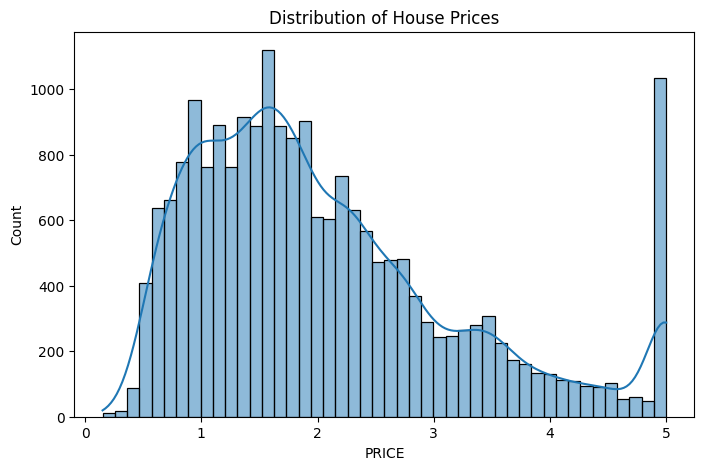

In [5]:
plt.figure(figsize=(8,5))

sns.histplot(data['PRICE'], kde=True)

plt.title("Distribution of House Prices")

plt.show()

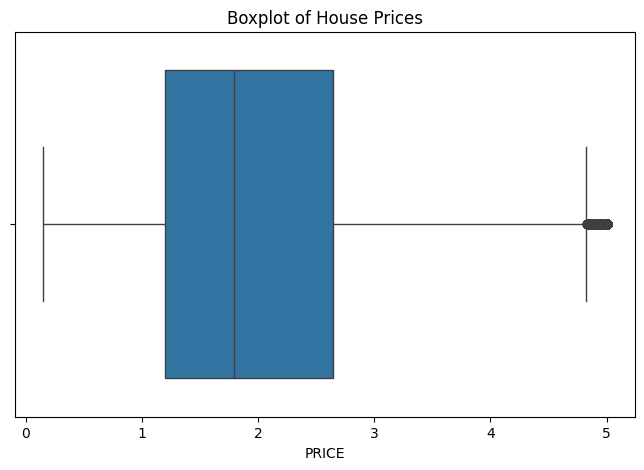

In [6]:
plt.figure(figsize=(8,5))

sns.boxplot(x=data['PRICE'])

plt.title("Boxplot of House Prices")

plt.show()

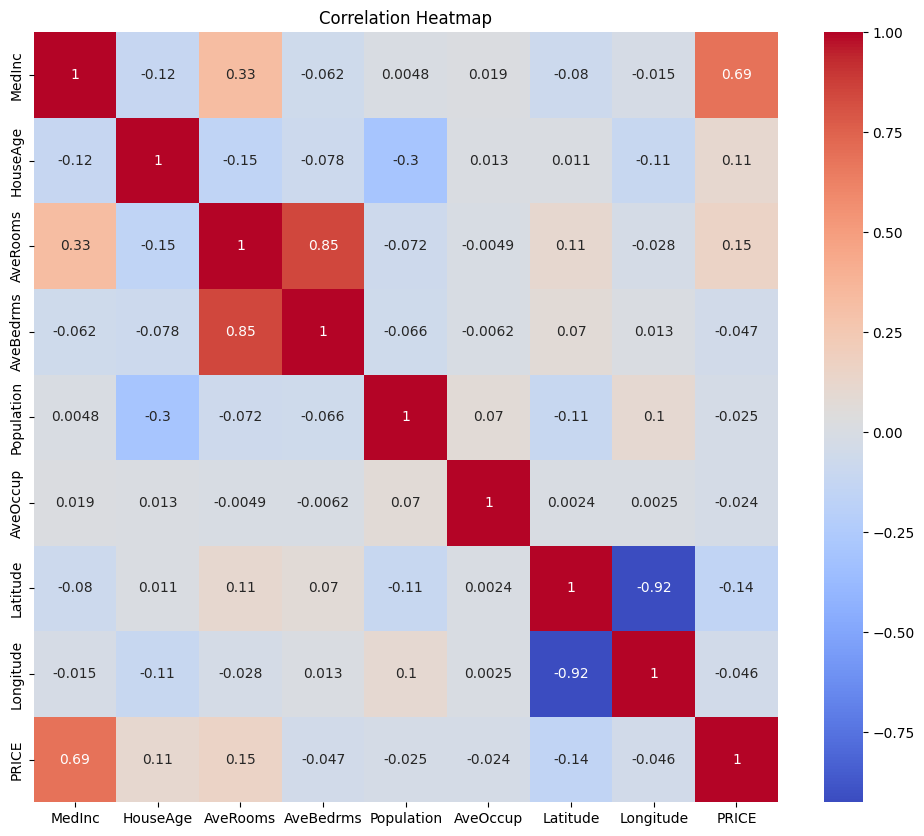

In [7]:
plt.figure(figsize=(12,10))

correlation = data.corr()

sns.heatmap(correlation, annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

In [8]:
X = data.iloc[:, :-1]

y = data['PRICE']

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [10]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [11]:
lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

mse_lr = mean_squared_error(y_test, y_pred_lr)

mae_lr = mean_absolute_error(y_test, y_pred_lr)

r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Results")

print("MSE:", mse_lr)

print("MAE:", mae_lr)

print("R2 Score:", r2_lr)

Linear Regression Results
MSE: 0.5558915986952442
MAE: 0.5332001304956565
R2 Score: 0.575787706032451


In [12]:
model = Sequential()

model.add(Dense(128, activation='relu', input_dim=X_train.shape[1]))

model.add(Dense(64, activation='relu'))

model.add(Dense(32, activation='relu'))

model.add(Dense(16, activation='relu'))

model.add(Dense(1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
model.compile(
    optimizer='adam',
    loss='mean_squared_error',
    metrics=['mae']
)

In [14]:
history = model.fit(
    X_train,
    y_train,
    epochs=100,
    validation_split=0.1,
    verbose=1
)

Epoch 1/100
465/465 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 0.7723 - mae: 0.5920 - val_loss: 0.4183 - val_mae: 0.4494
Epoch 2/100
465/465 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.3656 - mae: 0.4269 - val_loss: 0.3775 - val_mae: 0.4282
Epoch 3/100
465/465 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.3413 - mae: 0.4120 - val_loss: 0.3763 - val_mae: 0.4492
Epoch 4/100
465/465 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.3250 - mae: 0.3994 - val_loss: 0.3582 - val_mae: 0.4251
Epoch 5/100
465/465 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.3144 - mae: 0.3910 - val_loss: 0.3389 - val_mae: 0.4095
Epoch 6/100
465/465 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3065 - mae: 0.3870 - val_loss: 0.3506 - val_mae: 0.4060
Epoch 7/100
465/465 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3004 - mae: 0.3807 - val_loss: 0.3366 - val_mae: 0.4073
Epoch 8/100
465/465 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2942 - mae: 0.3756 - val_loss: 0.3291 - val_mae: 0.3847
Epoch 9/100
465/465 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/

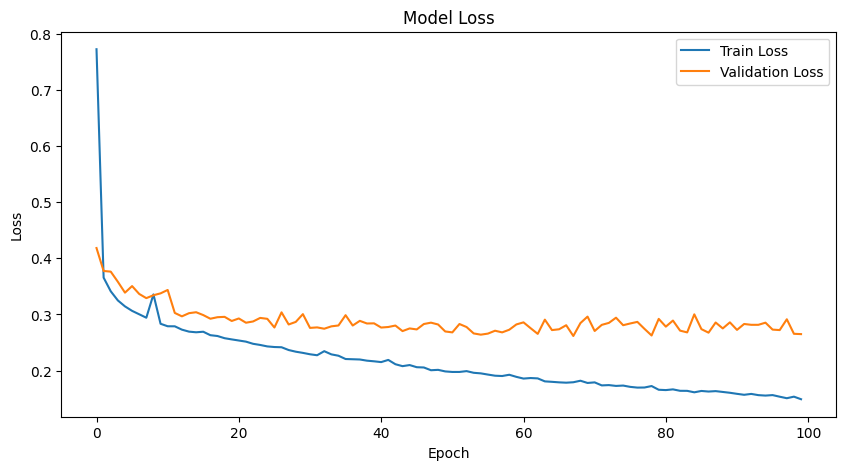

In [15]:
plt.figure(figsize=(10,5))

plt.plot(history.history['loss'], label='Train Loss')

plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Model Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.show()

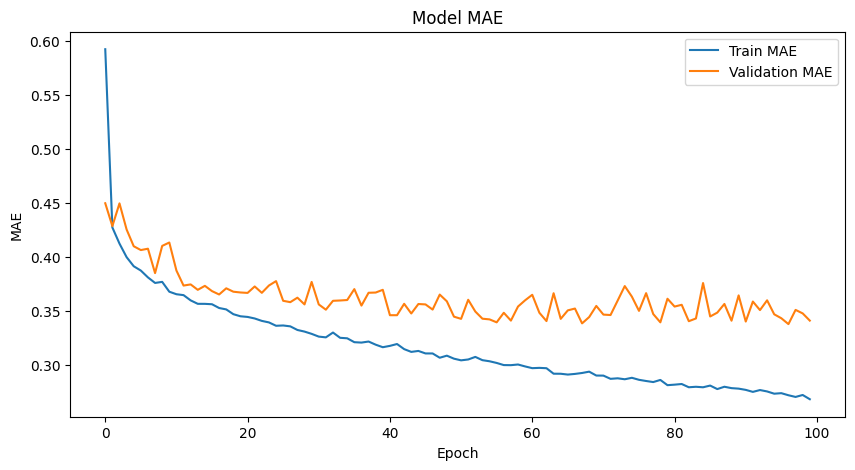

In [16]:
plt.figure(figsize=(10,5))

plt.plot(history.history['mae'], label='Train MAE')

plt.plot(history.history['val_mae'], label='Validation MAE')

plt.title("Model MAE")

plt.xlabel("Epoch")

plt.ylabel("MAE")

plt.legend()

plt.show()

In [17]:
y_pred_nn = model.predict(X_test)

mse_nn = mean_squared_error(y_test, y_pred_nn)

mae_nn = mean_absolute_error(y_test, y_pred_nn)

r2_nn = r2_score(y_test, y_pred_nn)

print("Deep Neural Network Results")

print("MSE:", mse_nn)

print("MAE:", mae_nn)

print("R2 Score:", r2_nn)

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Deep Neural Network Results
MSE: 0.25794458750066074
MAE: 0.3312282080757942
R2 Score: 0.8031571884932237


In [18]:
new_data = [[
    8.3252,
    41.0,
    6.984,
    1.023,
    322.0,
    2.555,
    37.88,
    -122.23
]]

new_data = scaler.transform(new_data)

prediction = model.predict(new_data)

print("Predicted House Price:", prediction[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
Predicted House Price: 4.0114164


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
